In [1]:
import sys
sys.path.append('..')

from root import ROOT
from data.fwf_dataset import FwfDataset

from omegaconf import OmegaConf
import os
import json
import numpy as np
import pandas as pd

In [2]:
import torch
def deconstruct_dict(
    input_dict:dict,
    input_keys =['features_neibors', 'features_point', 'wfm_neibors', 'wfm_point']
):
    # deconstruct dict
    input_shapes = {}
    input_flat = []
    for k,v in input_dict.items():
        if k not in input_keys: 
            continue
        # print(f'{k}: {list(v.shape)}')
        v_flat = v.reshape(v.shape[0],-1)
        input_shapes[k] = v.shape[1:]
        input_flat.append(v_flat)
    input_flat = torch.cat(input_flat, dim=1)
    return input_flat,input_shapes


# reconstruct dict
def reconstruct_dict(
    grads_flat: torch.Tensor,
    input_shapes: dict,
    input_keys =['features_neibors', 'features_point', 'wfm_neibors', 'wfm_point'],
):
    index_pointer = 0
    grads_dict = {k:None for k in input_keys}
    for k in input_keys:
        s = input_shapes[k]
        flat_size = torch.prod(torch.tensor(s))
        grads_dict[k] = grads_flat[:,index_pointer:index_pointer+flat_size].reshape(-1,*list(s)).contiguous()
        index_pointer += flat_size
    return grads_dict

In [4]:
from data.fwf_dataset import FwfDataset
from models.fgf import FGFeatNetwork
from utils.metrics import get_multilevel_metrics, print_metrics, combine_metrics_list, EarlyStopping, simple_metrics
from utils.general import generate_timestamp

from argparse import ArgumentParser
from tqdm import tqdm
from time import time
import numpy as np
import json
import os

import torch
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from omegaconf import OmegaConf

# metrics computation alternatives
from sklearn.metrics import jaccard_score
from torchmetrics.segmentation import MeanIoU

import pandas as pd
from plyfile import PlyData, PlyElement
from torch.nn.functional import softmax
import pickle

from captum.attr import IntegratedGradients
from torch.nn.functional import softmax










# parser = ArgumentParser()
# parser.add_argument('-e', '--exp_dir',help='Directory with the model .pth file and the training config, e.g. ./exp/2024-12-16_16-04-25_v006')
# parser.add_argument('-m', '--model_version', default='latest_model.pth')
# parser.add_argument('-v', '--voxel_size', type=float, default=0.1, help='voxel size with which to sample the point cloud')
# parser.add_argument('--return_probs', action='store_true')
# parser.add_argument('--return_embeddings', action='store_true')
# parser.add_argument('--test_on_train', action='store_true')

# args = parser.parse_args()

args_exp_dir = f'{ROOT}/exp/batch_6/run_0/2025-01-14_01-54-26_v606'
args_model_version = 'best_model.pth'
args_voxel_size = 0.05
args_return_probs = False
args_return_embeddings =False
args_test_on_train = False
args_save_feats = False
args_save_attributions = True
args_save_gt = False
args_save_pred = False


output_dir = os.path.join(args_exp_dir,'sensitivity_analysis')

# build config

cfg = OmegaConf.load(os.path.join(args_exp_dir,'config.yaml'))
cfg.general.root = ROOT
# overwrite root for notebook
cfg.data.dataset_root = os.path.join(cfg.general.root,cfg.data.dataset_root)
# overwrite batch size
# cfg.general.batch_size = 256
cfg.testing.batch_size = 48
with open(os.path.join(cfg.data.dataset_root, 'class_dict.json'),'r') as f:
    cfg = OmegaConf.merge(cfg, OmegaConf.create({'data':{'label_schema':json.load(f)}}))

cfg.general.batch_size
if 'embedding_size' not in cfg.model.keys():
    cfg.model.embedding_size = 128
print(OmegaConf.to_yaml(cfg))


experiment:
  title_suffix: v606
  description: Is geometric information relevant (compare with v003 )
general:
  device: cuda
  batch_size: 1024
  weight_decay: 0.0005
  max_epochs: 25
  early_stopping_minDelta: 0.01
  num_workers: 4
  root: /media/hristo/sharedData1/00_Projects/24-10-26_SPP_PCS/03_Code/fg-feat-extractor
data:
  dataset_root: /media/hristo/sharedData1/00_Projects/24-10-26_SPP_PCS/03_Code/fg-feat-extractor/../../02_Datasets/FWF_Subsampled/0.01_simple/
  split: ./config/default_split.yaml
  preprocessing:
    _transformsTraining_:
      xyz:
        TransCenterXyz: {}
        TransStandardize:
          mean:
          - - 0.0
            - 0.0
            - 0.0
          std:
          - - 0.16520438
            - 0.16500595
            - 0.1348829
        TransZRotation: {}
        TransScaling: {}
        TransGaussianNoise: {}
      rgb:
        TransStandardize:
          mean:
          - - 0.410554
            - 0.439411
            - 0.345924
          std:
    

# Perform attribution using integrated gradients

In [3]:
report = {} # project, label_level, overall, classwise
project_names = cfg.data._testProjects_ if not args_test_on_train else cfg.data._trainProjects_

for test_project in project_names:
    test_ds = FwfDataset(cfg, cfg.data.preprocessing._transformsValidation_, [test_project],
                        return_resiIdx=True, return_projIdx=True)
    proj_name = test_ds.projects[0]['proj_name']
    print(proj_name)
    
    test_ds.subsample_grid(args_voxel_size, save_inv=True)
    test_ds.compute_neibors_knn(k=cfg.data.num_neib_normalsComputation)
    test_ds.compute_normals_knn()
    test_ds.compute_incAngles()
    test_ds.compute_neibors_knn(k=cfg.data.num_neib_featureExtraction, verbose=True)
    model = FGFeatNetwork(cfg=cfg,
        num_input_feats = test_ds[0]['features_neibors'].shape[-1],
        ).to(device=cfg.general.device)
    model.load_state_dict(torch.load(os.path.join(args_exp_dir,args_model_version), weights_only=True))
    model = model.eval()
    
    test_dl = DataLoader(test_ds, batch_size=cfg.testing.batch_size, num_workers=cfg.general.num_workers)

    

    # initiate containers
    all_preds = [dict() for p in test_ds.projects]

    if args_return_probs:
        all_probs = [dict() for p in test_ds.projects]


    for pi, proj in enumerate(test_ds.projects):
        for label_name in test_ds.label_names:

            all_preds[pi][label_name] = torch.ones(size = (test_ds.projects[pi]['xyz_sub'].shape[0],)).to(
                device=cfg.general.device,dtype=torch.int64)*-1
            if args_return_probs:
                all_probs[pi][label_name] = torch.ones(size = (test_ds.projects[pi]['xyz_sub'].shape[0],
                    len(cfg.data.label_schema[label_name]))).to(device=cfg.general.device,dtype=torch.float32)*-1

    if args_return_embeddings:                
        embeddings = list()
        for pi, proj in enumerate(test_ds.projects):
            embeddings.append(torch.zeros(size=(test_ds.projects[pi]['xyz_sub'].shape[0],cfg.model.embedding_size)).to(device=cfg.general.device))

    if args_save_attributions:
        all_attributions = dict(
            features_neibors=list(),
            features_point=list(),
            wfm_neibors=list(),
            wfm_point=list()
        )
    # run test loop
    for batch in tqdm(test_dl):
        # put batch on device
        for k, v in batch.items():
            batch[k] = v.to(device=cfg.general.device)
            if ('labels' not in k) and ('idx' not in k):
                batch[k].requires_grad = True
        if args_return_embeddings:
            out = model(batch, return_embedding=True)
        else:
            out = model(batch)
        probs = dict()
        for k,v in [(k,v) for k,v in out.items() if k != 'embedding']:
            probs[k] = softmax(v,dim=-1)
            preds = torch.argmax(probs[k], dim=-1)
            all_preds[0][k][batch['residual_idx']] = preds # assume dataset has one project inside !
            if args_return_probs:
                all_probs[0][k][batch['residual_idx']] = probs[k]
            if args_return_embeddings:
                embeddings[0][batch['residual_idx']] = out['embedding']


        # attributions
        if args_save_attributions:
            inputs_flat, input_shapes = deconstruct_dict(input_dict=batch)
            func = lambda x : softmax(model(reconstruct_dict(x, input_shapes))['labels_3'], dim=1)
            target = out['labels_3'].argmax(dim=-1)
            ig = IntegratedGradients(func)
            baseline = torch.zeros_like(inputs_flat).to(cfg.general.device)
            attributions, error = ig.attribute(inputs=inputs_flat,baselines=baseline,target=target, return_convergence_delta=True, method='riemann_middle')
            attributions = reconstruct_dict(attributions, input_shapes)
            all_attributions['features_neibors'].append(attributions['features_neibors'].sum(dim=1).detach().cpu().numpy())
            all_attributions['features_point'].append(torch.squeeze(attributions['features_point']).detach().cpu().numpy())
            all_attributions['wfm_neibors'].append(attributions['wfm_neibors'].sum(dim=[1,2]).detach().cpu().numpy())
            all_attributions['wfm_point'].append(torch.squeeze(attributions['wfm_point']).sum(dim=-1).detach().cpu().numpy())
            
            
            # raise Exception

    # convert to numpy and upsample
    for k in cfg.data.label_names:
        all_preds[0][k] = all_preds[0][k].cpu().detach().numpy()
        all_preds[0][k] = all_preds[0][k][test_ds.projects[0]['sub_inv']]
        if args_return_probs:
            all_probs[0][k] = all_probs[0][k].cpu().detach().numpy()
            all_probs[0][k] = all_probs[0][k][test_ds.projects[0]['sub_inv']]
        

    

    # map dataset field names to single columns
    column_names_from_fields = {
        'xyz' : ['x','y','z'], 
        'rgb' : ['Red', 'Green','Blue'], 
        'riegl_feats' : ['riegl_reflectance','riegl_amplitude', 'riegl_deviation', 'riegl_targetIndex','riegl_targetCount'], 
        'geom_feats' : ['linearity','planarity','sphericity','omnivariance','anisotropy','eigenentropy',], 
        'normals' : ['nx','ny','nz'], 
        'incAngles' : ['incAngles'], 
        'distanceFromScanner' : ['distanceFromScanner'], 
    }
    # undo normalization
    # TODO: undo transforms by implementing an inverse transform to each class
    # test_ds.projects[0]['rgb'] *= np.array([[0.21558372, 0.23351644, 0.21213871]])
    # test_ds.projects[0]['rgb'] += np.array([[0.29689665, 0.3428666,  0.190237]])
    # test_ds.projects[0]['riegl_feats'] *= np.array([[  2.32590898, 2.98518547, 929.71399545, 1., 0.22651793]])
    # test_ds.projects[0]['riegl_feats'] += np.array([[-6.90191949, 25.16398933, 26.45952891,  1., 1.03636612]])
    output_fields = cfg.data.scalar_input_fields if args_save_feats else ['xyz']
    out_data = [test_ds.projects[0][k] for k in output_fields]
    out_column_names = [s for ss in [column_names_from_fields[f] for f in output_fields] for s in ss]
    
    # get ground_truth labels
    if args_save_gt:
        gt_names = [f"gt_{g}" for g in test_ds.label_names]
        gt_labels = test_ds.projects[0]['labels']
        out_data.append(gt_labels)
        out_column_names += gt_names
    
    # predictions
    if args_save_pred:
        pr_names = [f"pr_{g}" for g in test_ds.label_names]
        pr_labels = [all_preds[0][g][:,None] for g in test_ds.label_names]
        out_data += pr_labels
        out_column_names += pr_names

    # probabilities
    if args_return_probs:
        prob_names = [i for ii in [cfg.data.label_schema[level] for level in test_ds.label_names] for i in ii] # FIXME: Only works for single levels at a time
        prob_data = [all_probs[0][g] for g in test_ds.label_names]
        out_data += prob_data
        out_column_names += prob_names

    # attributions
    if args_save_attributions:
        feat_names = [s for ss in [column_names_from_fields[f] for f in cfg.data.scalar_input_fields] for s in ss]
        feat_names.pop(feat_names.index('riegl_targetIndex'))
        all_attrib_column_names = []
        for k in all_attributions.keys():
            # concatenate
            all_attributions[k] = np.concatenate(all_attributions[k], axis=0)
            # # upsample
            all_attributions[k] = all_attributions[k][test_ds.projects[0]['sub_inv']]
            # add axis
            if len(all_attributions[k].shape) == 1:
                all_attributions[k] = all_attributions[k][:, None]
                all_attrib_column_names += [k]
            # # add column names
            elif all_attributions[k].shape[-1] == len(feat_names):
                all_attrib_column_names += [f'{k}_{fn}' for fn in feat_names]

	
                
        all_attributions = np.concatenate(list(all_attributions.values()),axis=-1)
        out_data.append(all_attributions)
        out_column_names += all_attrib_column_names
            
    

    # break
    pcd = pd.DataFrame(np.concatenate(out_data,axis=-1), columns=out_column_names)
    os.makedirs(output_dir, exist_ok=True)
    PlyData([PlyElement.describe(pcd.to_records(index=False),'vertex')]).write(os.path.join(output_dir,proj_name.replace("::","--")+".ply"))
    # raise Exception

    # # save embeddings + inverse indices
    # # TODO:
    
    
    # # metrics
    # # FIXME: shapes, indices, etc. will break for more projects and or more than one label levels
    # report[proj_name] = dict()
    # for li, l in enumerate(test_ds.label_names):
    #     metrics = simple_metrics(np.squeeze(gt_labels), np.squeeze(pr_labels), len(cfg.data.label_schema[l]))
    #     report[proj_name][l] = metrics
    
    # # overwrite report
    # # report_name = 'report.pkl' if not args_test_on_train else 'report_on_train.pkl'
    # with open(os.path.join(output_dir,'report.pkl'),'wb') as f:
    #     pickle.dump(report,f)



experiment:
  title_suffix: v606
  description: Is geometric information relevant (compare with v003 )
general:
  device: cuda
  batch_size: 1024
  weight_decay: 0.0005
  max_epochs: 25
  early_stopping_minDelta: 0.01
  num_workers: 4
  root: /media/hristo/sharedData1/00_Projects/24-10-26_SPP_PCS/03_Code/fg-feat-extractor
data:
  dataset_root: /media/hristo/sharedData1/00_Projects/24-10-26_SPP_PCS/03_Code/fg-feat-extractor/../../02_Datasets/FWF_Subsampled/0.01_simple/
  split: ./config/default_split.yaml
  preprocessing:
    _transformsTraining_:
      xyz:
        TransCenterXyz: {}
        TransStandardize:
          mean:
          - - 0.0
            - 0.0
            - 0.0
          std:
          - - 0.16520438
            - 0.16500595
            - 0.1348829
        TransZRotation: {}
        TransScaling: {}
        TransGaussianNoise: {}
      rgb:
        TransStandardize:
          mean:
          - - 0.410554
            - 0.439411
            - 0.345924
          std:
    

100%|██████████| 44937/44937 [3:24:37<00:00,  3.66it/s]  


Loading '2024-04-05_FW_Westbahnhof_01.FwfProj'; Bounding box IDs = default
2024-04-05_FW_Westbahnhof_01.FwfProj::defaultBbox
Computing neibors for '2024-04-05_FW_Westbahnhof_01.FwfProj::defaultBbox' @ k=20
Computing normals and geom_feats for '2024-04-05_FW_Westbahnhof_01.FwfProj::defaultBbox' @ k=20
Computing incidence angles for '2024-04-05_FW_Westbahnhof_01.FwfProj::defaultBbox'
Computing neibors for '2024-04-05_FW_Westbahnhof_01.FwfProj::defaultBbox' @ k=128


100%|██████████| 3449/3449 [15:21<00:00,  3.74it/s]


Loading '2024-07-31_FW_Bruecke_Koenigstr.FwfProj'; Bounding box IDs = [1]
2024-07-31_FW_Bruecke_Koenigstr.FwfProj::bboxId=001
Computing neibors for '2024-07-31_FW_Bruecke_Koenigstr.FwfProj::bboxId=001' @ k=20
Computing normals and geom_feats for '2024-07-31_FW_Bruecke_Koenigstr.FwfProj::bboxId=001' @ k=20
Computing incidence angles for '2024-07-31_FW_Bruecke_Koenigstr.FwfProj::bboxId=001'
Computing neibors for '2024-07-31_FW_Bruecke_Koenigstr.FwfProj::bboxId=001' @ k=128


100%|██████████| 13740/13740 [1:01:24<00:00,  3.73it/s]


Loading '2024-08-02_FW_Bruecke_Kasinostrasse.FwfProj'; Bounding box IDs = [0]
2024-08-02_FW_Bruecke_Kasinostrasse.FwfProj::bboxId=000
Computing neibors for '2024-08-02_FW_Bruecke_Kasinostrasse.FwfProj::bboxId=000' @ k=20
Computing normals and geom_feats for '2024-08-02_FW_Bruecke_Kasinostrasse.FwfProj::bboxId=000' @ k=20
Computing incidence angles for '2024-08-02_FW_Bruecke_Kasinostrasse.FwfProj::bboxId=000'
Computing neibors for '2024-08-02_FW_Bruecke_Kasinostrasse.FwfProj::bboxId=000' @ k=128


100%|██████████| 15017/15017 [1:07:06<00:00,  3.73it/s]


Loading '2024-07-31_FW_Bruecke_Turmstr.FwfProj'; Bounding box IDs = default
2024-07-31_FW_Bruecke_Turmstr.FwfProj::defaultBbox
Computing neibors for '2024-07-31_FW_Bruecke_Turmstr.FwfProj::defaultBbox' @ k=20
Computing normals and geom_feats for '2024-07-31_FW_Bruecke_Turmstr.FwfProj::defaultBbox' @ k=20
Computing incidence angles for '2024-07-31_FW_Bruecke_Turmstr.FwfProj::defaultBbox'
Computing neibors for '2024-07-31_FW_Bruecke_Turmstr.FwfProj::defaultBbox' @ k=128


100%|██████████| 29162/29162 [2:12:32<00:00,  3.67it/s]  


# Analyse the results

In [64]:
from glob import glob
from plyfile import PlyData, PlyElement
import pandas as pd

all_neib_relevance = list()
for pcd_fp in glob(os.path.join(args_exp_dir,'sensitivity_analysis','*.ply')):    
    print(os.path.basename(pcd_fp))
    pcd = pd.DataFrame.from_dict(PlyData.read(pcd_fp).elements[0].data)
    neib_relevance = pcd.abs().mean(axis=0).drop(['x','y','z'])[[c for c in pcd.columns if 'neib' in c]]
    # neib_relevance.sort_values(ignore_index=False)
    
    all_neib_relevance.append(neib_relevance)
    
neib_relevance = pcd.abs().mean(axis=0).drop(['x','y','z'])[[c for c in pcd.columns if 'neib' in c]]
neib_relevance.sort_values(ignore_index=False)
attrib_summary = pd.concat([a.T for a in all_neib_relevance],axis=1).T.mean().sort_values()
attrib_summary = attrib_summary.rename({k:k.replace('neibors_','').replace('features_','').replace('riegl_','') for k in attrib_summary.index}) 
attrib_summary = pd.DataFrame({
    'feature' : attrib_summary.index,
    'relevance' : attrib_summary.values,

})
attrib_summary

2024-04-05_FW_Westbahnhof_01.FwfProj--defaultBbox.ply
2023-08-28_FW_EingangBauing.FwfProj--defaultBbox.ply
2024-07-31_FW_Bruecke_Koenigstr.FwfProj--bboxId=001.ply
2024-08-02_FW_Bruecke_Kasinostrasse.FwfProj--bboxId=000.ply
2024-07-31_FW_Bruecke_Turmstr.FwfProj--defaultBbox.ply


,feature,relevance
0,x,0.001057
1,y,0.001644
2,omnivariance,0.001897
3,deviation,0.002421
4,z,0.011400
5,sphericity,0.013011
6,linearity,0.015799
7,planarity,0.016367
8,anisotropy,0.020535
9,ny,0.022664


In [65]:
color_blue = (64,127,183)
color_green = (0,177,183)
color_maigreen = (189,205,0)
color_orange = (246,168,0)
color_red = (204,7,30)
color_bordeaux = (161,16,53)
color_violett = (122,111,172)
color_magenta = (227, 0, 102)

c_coord =           [c/255. for c in color_violett]
c_geom =            [c/255. for c in color_maigreen]
c_normals =         [c/255. for c in color_bordeaux]
c_color =           [c/255. for c in color_blue]
c_riegl =           [c/255. for c in color_orange]
c_rawfwf =          [c/255. for c in color_magenta]
c_scantargetrel =   [c/255. for c in color_green]

oldNameToColor = {
'x':c_coord,
'y':c_coord,
'omnivariance':c_geom,
'deviation':c_riegl,
'z':c_coord,
'sphericity':c_geom,
'linearity':c_geom,
'planarity':c_geom,
'anisotropy':c_geom,
'ny':c_normals,
'targetCount':c_riegl,
'distanceFromScanner':c_scantargetrel,
'nx':c_normals,
'incAngles':c_scantargetrel,
'amplitude':c_riegl,
'nz':c_normals,
'eigenentropy':c_geom,
'Red':c_color,
'Blue':c_color,
'wfm_neibors':c_rawfwf,
'Green':c_color,
'reflectance':c_riegl,
}

oldNameToNewName = {
'x': 'x',
'y': 'y',
'omnivariance': 'Omnivariance',
'deviation': 'Deviation',
'z': 'z',
'sphericity': 'Sphericity',
'linearity': 'Linearity',
'planarity': 'Planarity',
'anisotropy': 'Anisotropy',
'ny': '$N_y$',
'targetCount': 'Target Count',
'distanceFromScanner': 'Distance From Scanner',
'nx': '$N_x$',
'incAngles': 'Angle of Incidence',
'amplitude': 'Amplitude',
'nz': '$N_z$',
'eigenentropy': 'Eigenentropy',
'Red': 'Red Channel',
'Blue': 'Blue Channel',
'wfm_neibors': 'Raw Waveform',
'Green': 'Green Channel',
'reflectance': 'Reflectance',
}
attrib_summary['color'] = attrib_summary['feature'].apply(lambda x: [c for c in oldNameToColor[x]])
attrib_summary['feature'] = attrib_summary['feature'].apply(lambda x: oldNameToNewName[x])


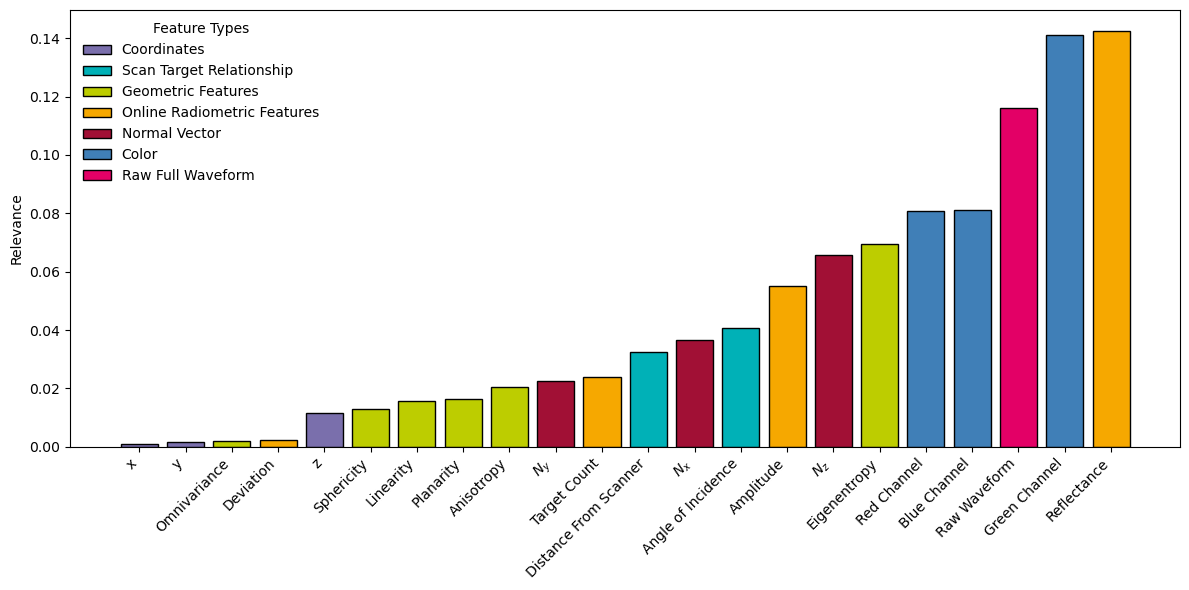

In [69]:
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
# Convert to pandas Series
df = attrib_summary

# Plot
plt.figure(figsize=(12, 6))
plt.bar(df["feature"], df["relevance"], color=df["color"], edgecolor="black", width=0.8)
# plt.title("Feature Relevance Bar Chart")
# plt.xlabel("Feature")
plt.ylabel("Relevance")
plt.xticks(rotation=45, ha="right")
legend_elements = [
    Patch(facecolor=c_coord, edgecolor='black', label='Coordinates'),
    Patch(facecolor=c_scantargetrel, edgecolor='black', label='Scan Target Relationship'),
    Patch(facecolor=c_geom, edgecolor='black', label='Geometric Features'),
    Patch(facecolor=c_riegl, edgecolor='black', label='Online Radiometric Features'),
    Patch(facecolor=c_normals, edgecolor='black', label='Normal Vector'),
    Patch(facecolor=c_color, edgecolor='black', label='Color'),
    Patch(facecolor=c_rawfwf, edgecolor='black', label='Raw Full Waveform'),
]

plt.legend(handles=legend_elements, title="Feature Types", edgecolor='none')
plt.tight_layout()
plt.savefig('./figures/feature_relevance.pdf')
# plt.show()


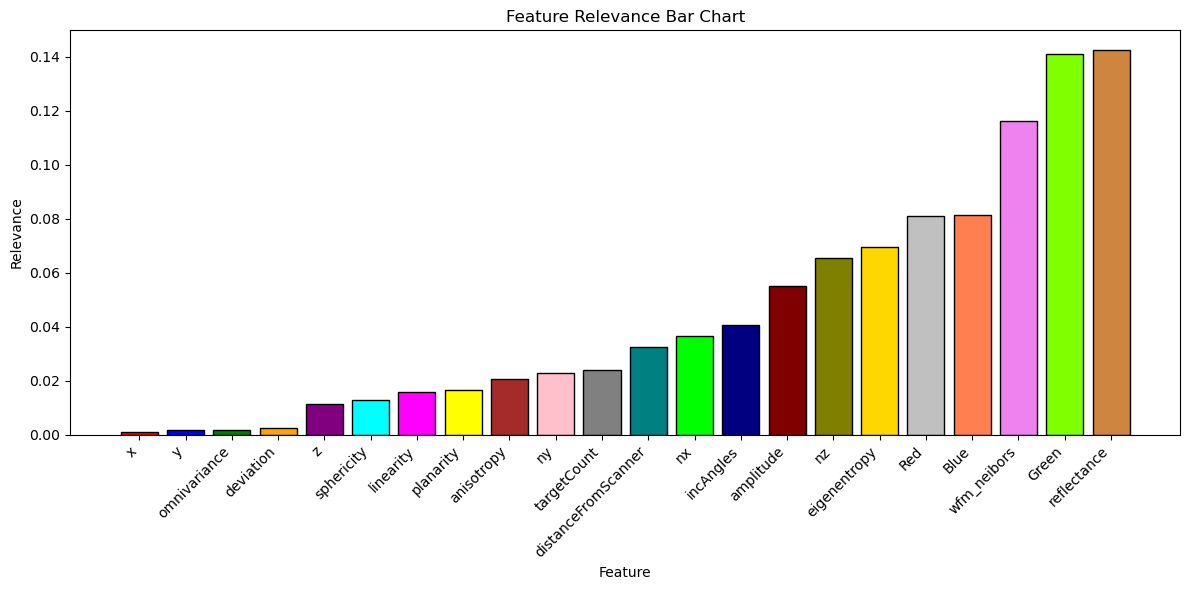

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with feature relevance and colors
data = {
    "feature": [
        "x", "y", "omnivariance", "deviation", "z", "sphericity", "linearity",
        "planarity", "anisotropy", "ny", "targetCount", "distanceFromScanner",
        "nx", "incAngles", "amplitude", "nz", "eigenentropy", "Red", "Blue",
        "wfm_neibors", "Green", "reflectance"
    ],
    "relevance": [
        0.001057, 0.001644, 0.001897, 0.002421, 0.011400, 0.013011,
        0.015799, 0.016367, 0.020535, 0.022664, 0.023857, 0.032623,
        0.036502, 0.040680, 0.054988, 0.065583, 0.069519, 0.080964,
        0.081158, 0.116077, 0.140987, 0.142563
    ],
    "color": [
        "red", "blue", "green", "orange", "purple", "cyan", "magenta",
        "yellow", "brown", "pink", "gray", "teal", "lime", "navy",
        "maroon", "olive", "gold", "silver", "coral", "violet",
        "chartreuse", "peru"
    ]
}

df = pd.DataFrame(data)

# Plot using the color column
plt.figure(figsize=(12, 6))
plt.bar(df["feature"], df["relevance"], color=df["color"], edgecolor="black", width=0.8)
plt.title("Feature Relevance Bar Chart")
plt.xlabel("Feature")
plt.ylabel("Relevance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
